In [1]:
!pip install torch_geometric #extend pytorch to provide layers and necessary tools required for building and training graph neural network
!pip install optuna #select best hyperparameters needed to train this model

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.3 MB/s eta 0:00:00


In [34]:
import torch
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.nn import Linear
from torch_geometric.nn import GCNConv

In [35]:
dataset=KarateClub()
data=dataset[0]

In [36]:
print(dataset.num_features)

34


In [37]:
import pandas as pd
node_features_df=pd.DataFrame(data.x.numpy(),columns=[f'feature_{i}' for i in range(dataset.num_features)])
node_features_df['node']=node_features_df.index
node_features_df.set_index('node',inplace=True)

edge_index_df=pd.DataFrame(data.edge_index.numpy().T,columns=['source','target'])
labels_df=pd.DataFrame(data.y.numpy(),columns=['label'])
labels_df['node']=labels_df.index
labels_df.set_index('node',inplace=True)


In [38]:
print(node_features_df)

      feature_0  feature_1  feature_2  ...  feature_31  feature_32  feature_33
node                                   ...                                    
0           1.0        0.0        0.0  ...         0.0         0.0         0.0
1           0.0        1.0        0.0  ...         0.0         0.0         0.0
2           0.0        0.0        1.0  ...         0.0         0.0         0.0
3           0.0        0.0        0.0  ...         0.0         0.0         0.0
4           0.0        0.0        0.0  ...         0.0         0.0         0.0
5           0.0        0.0        0.0  ...         0.0         0.0         0.0
6           0.0        0.0        0.0  ...         0.0         0.0         0.0
7           0.0        0.0        0.0  ...         0.0         0.0         0.0
8           0.0        0.0        0.0  ...         0.0         0.0         0.0
9           0.0        0.0        0.0  ...         0.0         0.0         0.0
10          0.0        0.0        0.0  ...         0

In [39]:
num_nodes=data.num_nodes
num_edges=data.edge_index.shape[1]
print(f'Number of nodes: {num_nodes}')
print(f'Number of edges: {num_edges}')

Number of nodes: 34
Number of edges: 156


In [40]:
print(f'\nNode features(shape : {node_features_df.shape}):')
print(node_features_df.head())


Node features(shape : (34, 34)):
      feature_0  feature_1  feature_2  ...  feature_31  feature_32  feature_33
node                                   ...                                    
0           1.0        0.0        0.0  ...         0.0         0.0         0.0
1           0.0        1.0        0.0  ...         0.0         0.0         0.0
2           0.0        0.0        1.0  ...         0.0         0.0         0.0
3           0.0        0.0        0.0  ...         0.0         0.0         0.0
4           0.0        0.0        0.0  ...         0.0         0.0         0.0

[5 rows x 34 columns]


In [41]:
print(f'\nEdge index(shape : {edge_index_df.shape}):')
print(edge_index_df.head())


Edge index(shape : (156, 2)):
   source  target
0       0       1
1       0       2
2       0       3
3       0       4
4       0       5


In [42]:
print(f'\nLabels(shape : {labels_df.shape}):')
print(labels_df.head())


Labels(shape : (34, 1)):
      label
node       
0         1
1         1
2         1
3         1
4         3


In [43]:
num_countries = 4
np.random.seed(42)
countries = torch.tensor(np.random.choice(num_countries, num_nodes))
data.y = countries

In [44]:
print(data)
print(f'x={data.x.shape}')
print(data.x)
print(f'edge_index={data.edge_index.shape}')
print(data.edge_index)
print(f'y={data.y.shape}')
print(data.y)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
x=torch.Size([34, 34])
tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
edge_index=torch.Size([2, 156])
tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 

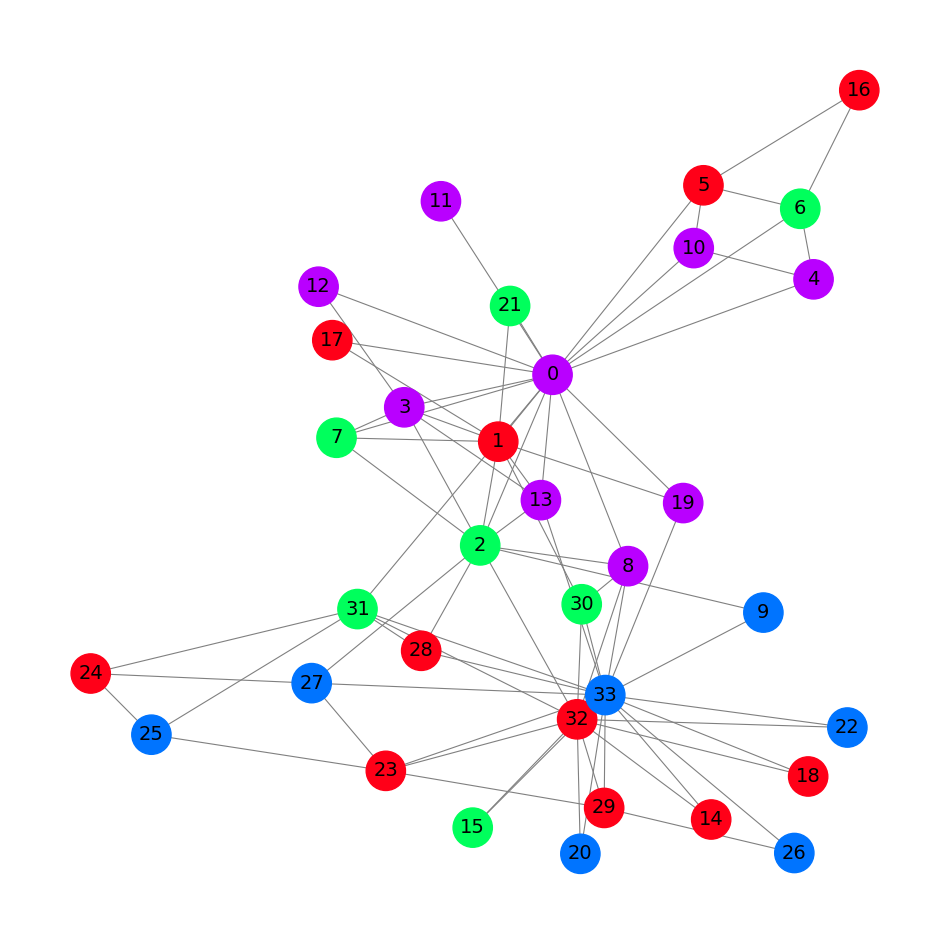

In [45]:
G=to_networkx(data,to_undirected=True)
plt.figure(figsize=(12,12))
plt.axis('off')
nx.draw_networkx(G,
                 pos=nx.spring_layout(G,seed=0),
                 with_labels=True,
                 node_size=800,
                 node_color=data.y,
                 cmap="hsv",
                 vmin=-2,
                 vmax=3,
                 width=0.8,
                 edge_color='grey',
                 font_size=14
)

In [46]:
class GCN(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.gcn=GCNConv(dataset.num_features,3)
    self.out=Linear(3,num_countries)
  def forward(self,x,edge_index):
    h=self.gcn(x,edge_index).relu()
    z=self.out(h)
    return h,z
model=GCN()
print(model)

GCN(
  (gcn): GCNConv(34, 3)
  (out): Linear(in_features=3, out_features=4, bias=True)
)


In [47]:
criterion=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.02)
def accuracy(pred_y,y):
  return ((pred_y==y).sum()/len(y))

In [48]:
embeddings=[]
losses=[]
accuracies=[]
outputs=[]

for epoch in range(200):
  optimizer.zero_grad()
  h, z=model(data.x,data.edge_index)
  loss=criterion(z,data.y)
  acc=accuracy(z.argmax(dim=1),data.y)
  loss.backward()
  optimizer.step()
  embeddings.append(h)
  losses.append(loss)
  accuracies.append(acc)
  outputs.append(z.argmax(dim=1))
  if epoch%10==0:
    print(f'Epoch: {epoch:>3}, Loss: {loss:.2f}, Accuracy: {acc*100:.2f}%')

Epoch:   0, Loss: 1.46, Accuracy: 20.59%
Epoch:  10, Loss: 1.33, Accuracy: 47.06%
Epoch:  20, Loss: 1.22, Accuracy: 47.06%
Epoch:  30, Loss: 1.12, Accuracy: 50.00%
Epoch:  40, Loss: 1.02, Accuracy: 52.94%
Epoch:  50, Loss: 0.90, Accuracy: 55.88%
Epoch:  60, Loss: 0.79, Accuracy: 61.76%
Epoch:  70, Loss: 0.67, Accuracy: 73.53%
Epoch:  80, Loss: 0.57, Accuracy: 76.47%
Epoch:  90, Loss: 0.50, Accuracy: 73.53%
Epoch: 100, Loss: 0.44, Accuracy: 94.12%
Epoch: 110, Loss: 0.38, Accuracy: 88.24%
Epoch: 120, Loss: 0.32, Accuracy: 88.24%
Epoch: 130, Loss: 0.28, Accuracy: 88.24%
Epoch: 140, Loss: 0.25, Accuracy: 88.24%
Epoch: 150, Loss: 0.22, Accuracy: 88.24%
Epoch: 160, Loss: 0.19, Accuracy: 91.18%
Epoch: 170, Loss: 0.17, Accuracy: 97.06%
Epoch: 180, Loss: 0.16, Accuracy: 97.06%
Epoch: 190, Loss: 0.14, Accuracy: 97.06%


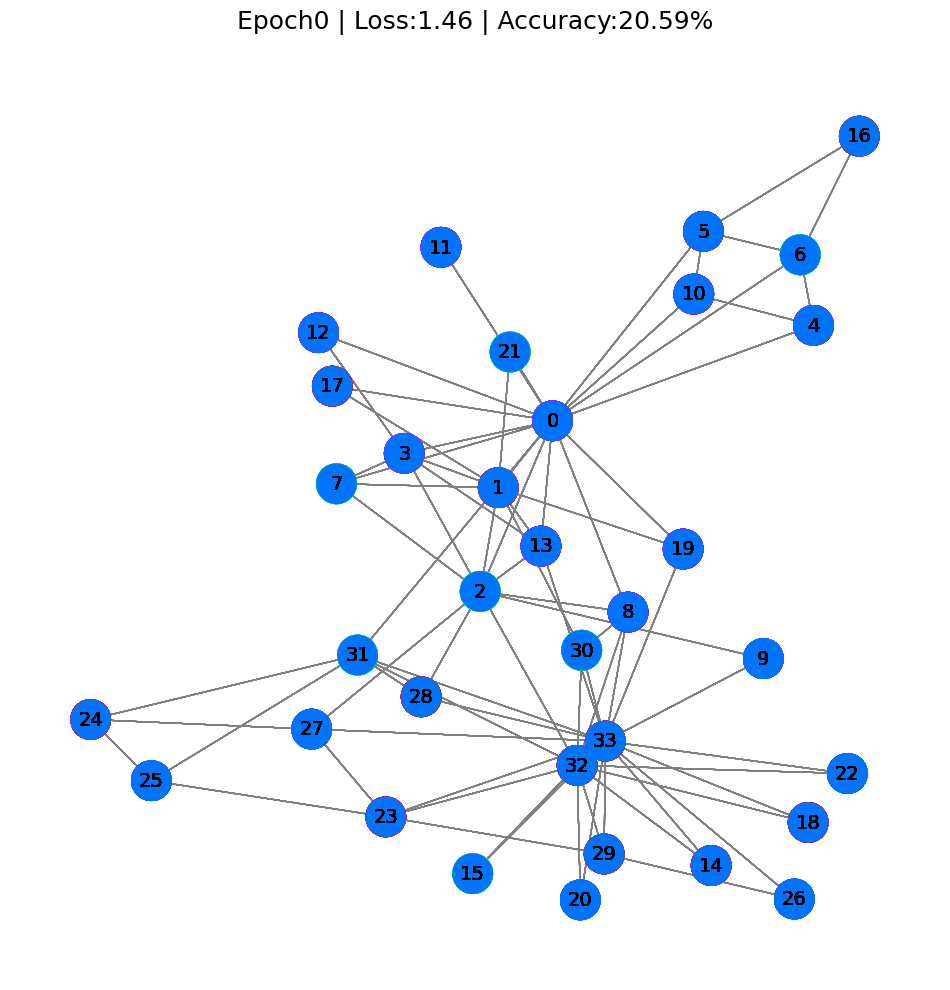

In [50]:
from IPython.display import HTML
from matplotlib import animation
plt.rcParams['animation.bitrate'] =3000
def animate(i):
  G=to_networkx(data,to_undirected=True)
  nx.draw_networkx(G,
                   pos=nx.spring_layout(G,seed=0),
                   with_labels=True,
                   node_size=800,
                   node_color=outputs[i].numpy(),
                   cmap="hsv",
                   vmin=-2,
                   vmax=3,
                   width=0.8,
                   edge_color='grey',
                   font_size=14
  )
  plt.title(f'Epoch{i} | Loss:{losses[i].item():.2f} | Accuracy:{accuracies[i].item()*100:.2f}%',fontsize=18,pad=20)
fig=plt.figure(figsize=(12,12))
plt.axis('off')
anim=animation.FuncAnimation(fig,animate,np.arange(0,200,10),interval=500,repeat=True)
html=HTML(anim.to_html5_video())
display(html)


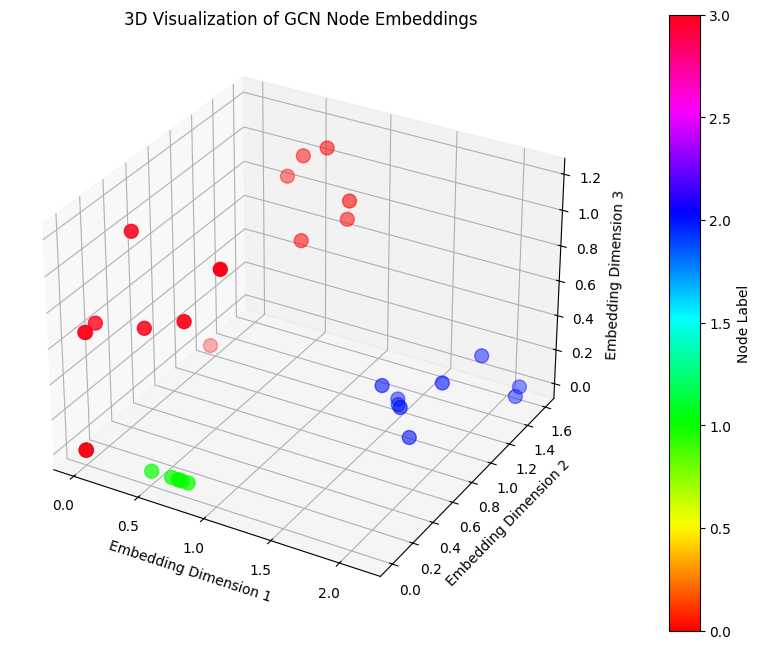

In [51]:
from mpl_toolkits.mplot3d import Axes3D

# Get the last computed embeddings and labels
h_final = embeddings[-1].detach().cpu().numpy()
y_final = data.y.detach().cpu().numpy()

# Create a 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot the embeddings
scatter = ax.scatter(h_final[:, 0], h_final[:, 1], h_final[:, 2], c=y_final, cmap='hsv', s=100)

# Set labels and title
ax.set_xlabel('Embedding Dimension 1')
ax.set_ylabel('Embedding Dimension 2')
ax.set_zlabel('Embedding Dimension 3')
ax.set_title('3D Visualization of GCN Node Embeddings')

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Node Label')

plt.show()